## SENTIMENT ANALYSIS MODEL - Logistic Regression


## Load data

In [29]:
import os
import pandas as pd

master_dir = os.path.dirname(os.getcwd())

file_dataset_train = os.path.join(master_dir, "dataset", "train_dataset_bilingual.csv")
file_dataset_test  = os.path.join(master_dir, "dataset", "test_dataset_bilingual.csv")
file_dataset_val   = os.path.join(master_dir, "dataset", "validate_dataset_bilingual.csv")

train_df = pd.read_csv(file_dataset_train)
test_df  = pd.read_csv(file_dataset_test)
val_df   = pd.read_csv(file_dataset_val)

train_df.head(10)

,Author,Rating,Review,Restaurant,Location,Label,Language
0,wu stephen,5,Good and fresh food,EverGreen Restaurant,JB,Positive,English
1,Nicole Lim,4,"Kami makan ponteh, ikan Assam, sotong kunyit,...",Restoran Nyonya Makko,Melaka,Positive,Malay
2,Mohd Khairuddin Jaafar,5,Nice meal,Restoran Kacang Pool Haji,JB,Positive,English
3,sze yah chng,3,"The curry taste more to like Johor type, more ...",W.W. Laksa House 水塘。辣沙,JB,Neutral,English
4,Sh Lim,4,"Satu, yang terbaik adalah JB Bak Kut Teh. Suk...",Restaurant Shun Fa Bak Kut Teh,JB,Positive,Malay
5,Thanabalan Vadivelu,2,I like the food,KAMPUNG CARABAO 100% Authentic Thai Restaurant,JB,Negative,English
6,Li Min Leong,4,Sashimi segar. Semua rasa YUMS.,Yaoki Japanese Foods Sdn. Bhd.,JB,Positive,Malay
7,Kim de Buck,5,Sebuah restoran kecil yang sangat selesa deng...,Trois by navy,Melaka,Positive,Malay
8,Robert Choong,4,Nice place 👍,Harvests Bar & Grill,JB,Positive,English
9,mimie aqilah mohd amran,4,Keep coming here for good Indian cuisine. staf...,7 Spice,JB,Positive,English


In [30]:
# test = True  - lightweight run on a small sample, for fast iteration / debugging
# test = False - full training run
test = False

# whether to export the finalized model/vectorizer/config at the end
exportModel = True  # {True, False}

RANDOM_STATE = 10  # single seed used everywhere for reproducibility

## Clean up & de-duplicate

In [31]:
def basic_cleanup(df):
    df = df[['Review', 'Rating']].copy()
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    return df

train_df = basic_cleanup(train_df)
test_df  = basic_cleanup(test_df)
val_df   = basic_cleanup(val_df)

print(f"train: {len(train_df)} rows | test: {len(test_df)} rows | val: {len(val_df)} rows")

train: 48292 rows | test: 16414 rows | val: 16411 rows


### Sanity check: overlap between splits

Before doing anything else, confirm there's no review text shared between train and test/val.
If there is, that's a leakage source independent of the label-mixing bug from the earlier review — worth knowing about even if it comes from the source data rather than our code.

In [32]:
train_reviews = set(train_df['Review'])
test_overlap = test_df['Review'].isin(train_reviews).sum()
val_overlap  = val_df['Review'].isin(train_reviews).sum()

print(f"Test reviews also present in train: {test_overlap} / {len(test_df)}")
print(f"Val reviews also present in train:  {val_overlap} / {len(val_df)}")
# If these numbers are non-trivial, investigate the source data before trusting test metrics.

Test reviews also present in train: 721 / 16414
Val reviews also present in train:  726 / 16411


In [33]:
val_df = val_df[~val_df['Review'].isin(train_df['Review'])]

# 2. Remove training reviews from the test set
test_df = test_df[~test_df['Review'].isin(train_df['Review'])]

In [34]:
train_reviews = set(train_df['Review'])
test_overlap = test_df['Review'].isin(train_reviews).sum()
val_overlap  = val_df['Review'].isin(train_reviews).sum()

print(f"Test reviews also present in train: {test_overlap} / {len(test_df)}")
print(f"Val reviews also present in train:  {val_overlap} / {len(val_df)}")
# If these numbers are non-trivial, investigate the source data before trusting test metrics.

Test reviews also present in train: 0 / 15693
Val reviews also present in train:  0 / 15685


In [35]:
print(f"train: {len(train_df)} rows | test: {len(test_df)} rows | val: {len(val_df)} rows")

train: 48292 rows | test: 15693 rows | val: 15685 rows


## Labeling

Keeping the original binary scheme: rating > 3 -> positive (2), rating < 3 -> negative (0),
rating == 3 -> neutral (1, excluded from this binary classifier).

In [36]:
def labelFunc(x):
    """3-class version: 2=positive, 1=neutral, 0=negative. Not used in this binary pipeline."""
    if int(x) > 3:
        return 2
    elif int(x) < 3:
        return 0
    elif int(x) == 3:
        return 1

def labelFunc2(x):
    """Binary version used here: 1=positive, 0=negative, -1=neutral (dropped downstream)."""
    if int(x) > 3:
        return 1
    elif int(x) < 3:
        return 0
    elif int(x) == 3:
        return -1

train_df["Label"] = train_df["Rating"].apply(labelFunc)
test_df["Label"]  = test_df["Rating"].apply(labelFunc)
val_df["Label"]   = val_df["Rating"].apply(labelFunc)

train_df.head(10)

,Review,Rating,Label
0,Good and fresh food,5,2
1,"Kami makan ponteh, ikan Assam, sotong kunyit,...",4,2
2,Nice meal,5,2
3,"The curry taste more to like Johor type, more ...",3,1
4,"Satu, yang terbaik adalah JB Bak Kut Teh. Suk...",4,2
5,I like the food,2,0
6,Sashimi segar. Semua rasa YUMS.,4,2
7,Sebuah restoran kecil yang sangat selesa deng...,5,2
8,Nice place 👍,4,2
9,Keep coming here for good Indian cuisine. staf...,4,2


### Check class imbalance (train)

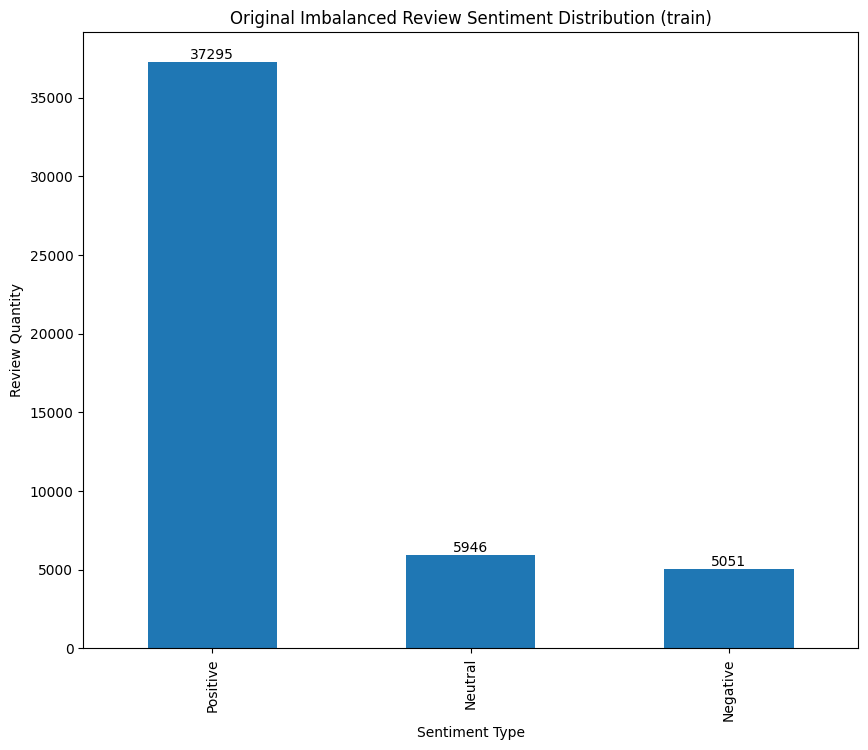

In [38]:
import matplotlib.pyplot as plt

mapping = {2: "Positive", 1: "Neutral", 0: "Negative"}
df_class = train_df['Label'].map(mapping).value_counts()

ax = df_class.plot(kind='bar', title='Original Imbalanced Review Sentiment Distribution (train)',
                    figsize=(10, 8), legend=False)
ax.bar_label(ax.containers[0])
ax.set_xlabel("Sentiment Type")
ax.set_ylabel("Review Quantity");

## Build train/test/val sentiment sets

In [ ]:
# ---- Train: undersample to 50/50 (this is a training-time decision only) ----
min_review_count = min(
    train_df[train_df['Label'] == 0].index.size,
    train_df[train_df['Label'] == 1].index.size,
    train_df[train_df['Label'] == 2].index.size,
)
print(f"Min class count in train: {min_review_count}")

df_train_neu = train_df[train_df['Label'] == 2].sample(min_review_count, random_state=RANDOM_STATE)
df_train_pos = train_df[train_df['Label'] == 1].sample(min_review_count, random_state=RANDOM_STATE)
df_train_neg = train_df[train_df['Label'] == 0].sample(min_review_count, random_state=RANDOM_STATE)

df_train_balanced = pd.concat([df_train_pos, df_train_neg, df_train_neu], ignore_index=True)

# ---- Test & val: keep natural distribution, just drop neutral ----
df_test_final = test_df[test_df['Label'].isin([0, 1,2])].reset_index(drop=True)
df_val_final  = val_df[val_df['Label'].isin([0, 1,2])].reset_index(drop=True)

print(f"Train (balanced): {len(df_train_balanced)} rows")

print(f"Test  (natural):  {len(df_test_final)} rows, "
      f"{df_test_final['Label'].mean()*100:.1f}% positive")

print(f"Val   (natural):  {len(df_val_final)} rows, "
      f"{df_val_final['Label'].mean()*100:.1f}% positive")

Min class count in train: 5051
Train (balanced): 15153 rows
Test  (natural):  15693 rows, 166.7% positive
Val   (natural):  15685 rows, 166.9% positive


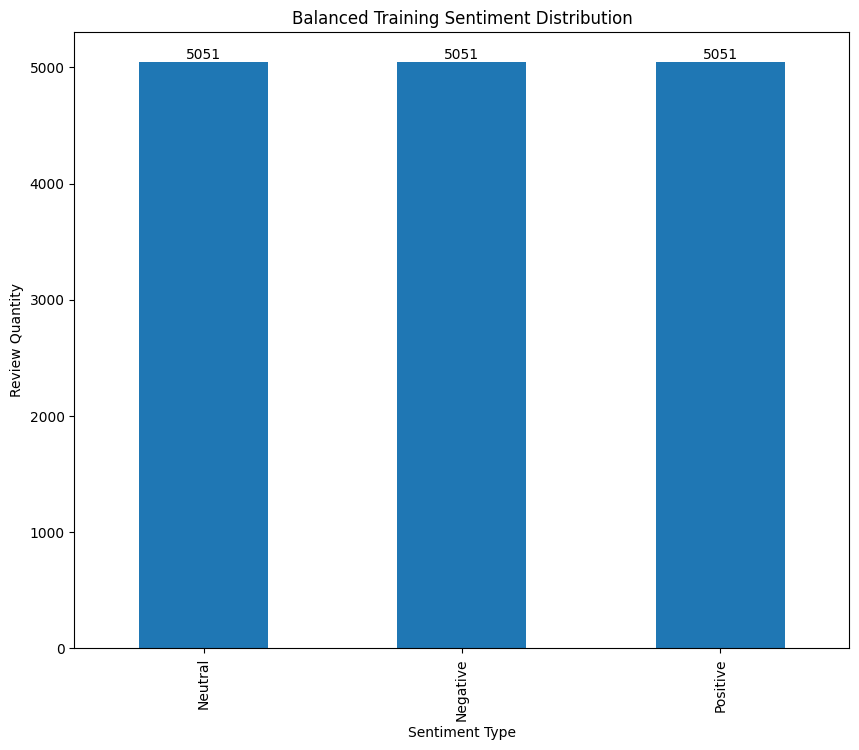

In [41]:

df_class2 = df_train_balanced['Label'].map(mapping).value_counts()

ax = df_class2.plot(kind='bar', title='Balanced Training Sentiment Distribution',
                     figsize=(10, 8), legend=False)
ax.bar_label(ax.containers[0])
ax.set_xlabel("Sentiment Type")
ax.set_ylabel("Review Quantity");

## Pre-processing / text cleaning


In [42]:
# Quick data checks (kept from original notebook, run on train before cleaning)
has_uppercase = train_df['Review'].str.contains(r'[A-Z]').sum()
print(f"Total reviews with uppercase letters: {has_uppercase} / {len(train_df)}")

has_noise = train_df['Review'].str.contains(r'[^a-zA-Z\s]').sum()
print(f"Total reviews with punctuation/digits/noise: {has_noise} / {len(train_df)}")

Total reviews with uppercase letters: 46632 / 48292
Total reviews with punctuation/digits/noise: 41457 / 48292


In [ ]:
import re

def clean_text(text):
    """Lowercase, strip punctuation/digits/symbols, collapse whitespace.
    Works on both English and Malay text since both use the Latin alphabet for this step -
    NOTE: this does NOT mean English and Malay are handled equivalently everywhere. Stemming/
    morphological handling (Malay affixes like me-/ber-/-kan) would need language-specific
    logic if added later; this function only covers character-level cleaning.
    """
    text = str(text)
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_balanced = df_train_balanced.copy()
df_test_natural = df_test_final.copy()
df_val_natural = df_val_final.copy()

df_balanced['Review']     = df_balanced['Review'].apply(clean_text)
df_test_natural['Review'] = df_test_natural['Review'].apply(clean_text)
df_val_natural['Review']  = df_val_natural['Review'].apply(clean_text)

df_balanced[['Review']].head(5)

,Review
0,the dinsum restaurant operates differently fro...
1,very tasty curry no parking space
2,food is good but service is slower than snail
3,dimsum is delicious but you have to add more t...
4,noisy


## Stopwords (bilingual: English + Malay)

In [44]:
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

stopwordz = set(stopwords.words("english"))
stopwordz.remove('not')  # keep negation - important for sentiment

malay_stops = {
    # Pronouns & People
    'saya', 'kami', 'kita', 'mereka', 'dia', 'awak', 'kamu', 'ia', 'anda',
    # Prepositions & Connectives
    'yang', 'di', 'dan', 'ke', 'dari', 'pada', 'untuk', 'dengan', 'atau',
    'serta', 'kerana', 'sebab', 'oleh', 'maka', 'hingga', 'sampai', 'tentang',
    # Demonstratives & Particles (Formal + Informal Slang)
    'ini', 'itu', 'ni', 'tu', 'lah', 'je', 'ja', 'jua', 'pun', 'ke', 'kan',
    # Verbs / Auxiliaries of Existence & Time
    'ada', 'adalah', 'ialah', 'telah', 'sudah', 'akan', 'pernah', 'sedang',
    'masih', 'boleh', 'dapat', 'hendak', 'mahu', 'nak', 'jadi',
    # High-Frequency Fillers
    'banyak', 'sangat', 'agak', 'amat', 'lagi', 'pula', 'seperti', 'paling'
}

bilingual_stopwords = sorted(stopwordz.union(malay_stops))
print(f"Total bilingual stopwords: {len(bilingual_stopwords)}")

Total bilingual stopwords: 256


## Train / test / val feature sets

In [ ]:
X_train, y_train = df_balanced['Review'], df_balanced['Label']
X_test,  y_test  = df_test_natural['Review'], df_test_natural['Label']
X_val,   y_val   = df_val_natural['Review'], df_val_natural['Label']

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}, X_val: {X_val.shape}")

X_train: (15153,), X_test: (15693,), X_val: (15685,)


## Baseline majority-class reference

a trivial baseline so later metrics can be judged against a real floor. If the real model can't beat this by a healthy margin,
something's wrong.

In [48]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Fits and predicts the most frequent class among your 3 classes
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
pred_dummy = dummy.predict(X_test)

print("Majority-class baseline on 3-class test set:")
print(f"  Accuracy:     {accuracy_score(y_test, pred_dummy):.3f}")
print(f"  Macro F1:     {f1_score(y_test, pred_dummy, average='macro', zero_division=0):.3f}")
print(f"  Weighted F1:  {f1_score(y_test, pred_dummy, average='weighted', zero_division=0):.3f}")

Majority-class baseline on 3-class test set:
  Accuracy:     0.106
  Macro F1:     0.064
  Weighted F1:  0.020


In [49]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred_dummy, zero_division=0))

              precision    recall  f1-score   support

           0       0.11      1.00      0.19      1659
           1       0.00      0.00      0.00      1913
           2       0.00      0.00      0.00     12121

    accuracy                           0.11     15693
   macro avg       0.04      0.33      0.06     15693
weighted avg       0.01      0.11      0.02     15693



## Pipeline & prototype model

In [56]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    (
        'vect',
        CountVectorizer(
            lowercase=True,
            stop_words=bilingual_stopwords,
            ngram_range=(1, 2),
            max_features=3000,
        ),
    ),
    (
        'clf',
        LogisticRegression(
            max_iter=2000,
            class_weight='balanced',  # Added because your dataset is heavily imbalanced!
            random_state=RANDOM_STATE,
        ),
    ),
])

# 1. Define active training set depending on test flag
if test:
    sample_idx = X_train.sample(500, random_state=RANDOM_STATE).index
    X_train_active = X_train.loc[sample_idx]
    y_train_active = y_train.loc[sample_idx]
else:
    X_train_active = X_train
    y_train_active = y_train

# 2. Fit pipeline on training data
pipeline.fit(X_train_active, y_train_active)

# 3. Predict on training data
pred_train = pipeline.predict(X_train_active)

# 4. Compute training metrics (using average='macro' for 3 classes)
print("--- Training Metrics (3-Class) ---")
print(
    'Logistic_train_accuracy: '
    f' {accuracy_score(y_train_active, pred_train):.3f}'
)
print(
    'Logistic_train_precision:'
    f" {precision_score(y_train_active, pred_train, average='macro', zero_division=0):.3f}"
)
print(
    'Logistic_train_recall:   '
    f" {recall_score(y_train_active, pred_train, average='macro', zero_division=0):.3f}"
)
print(
    'Logistic_train_f1:       '
    f" {f1_score(y_train_active, pred_train, average='macro', zero_division=0):.3f}"
)

--- Training Metrics (3-Class) ---
Logistic_train_accuracy:  0.761
Logistic_train_precision: 0.761
Logistic_train_recall:    0.761
Logistic_train_f1:        0.761


In [57]:
from sklearn.metrics import classification_report

# Detailed report showing per-class performance
print(
    classification_report(
        y_train_active, pred_train, zero_division=0, digits=3
    )
)

              precision    recall  f1-score   support

           0      0.817     0.792     0.805      5051
           1      0.692     0.667     0.679      5051
           2      0.773     0.825     0.798      5051

    accuracy                          0.761     15153
   macro avg      0.761     0.761     0.761     15153
weighted avg      0.761     0.761     0.761     15153



In [ ]:
import pandas as pd

vect_step = pipeline.named_steps['vect']
clf_step = pipeline.named_steps['clf']

feature_names = vect_step.get_feature_names_out()

class_labels = clf_step.classes_

for i, class_label in enumerate(class_labels):
    # Get coefficients for class i
    coef_df = pd.DataFrame(
        clf_step.coef_[i], index=feature_names, columns=['coef']
    ).sort_values(by='coef', ascending=False)

    print(f"=== Top 10 Words for Class '{class_label}' ===")
    print(coef_df.head(10))
    print('\n' + '-' * 40 + '\n')

=== Top 10 Words for Class '0' ===
                    coef
worst           1.724328
not worth       1.721888
terrible        1.708946
rude            1.575583
horrible        1.549485
reviews         1.549405
disappointing   1.507539
not nice        1.464382
tidak berbaloi  1.445140
poor            1.442477

----------------------------------------

=== Top 10 Words for Class '1' ===
                coef
tersedia    1.296125
suka pizza  1.192260
antara      1.147801
juga ingin  1.126917
sedap ikan  1.072898
acceptable  1.019847
alright     0.966139
terpaksa    0.965821
really bad  0.962709
reasonably  0.944396

----------------------------------------

=== Top 10 Words for Class '2' ===
                coef
not bad     1.986040
excellent   1.702772
perfect     1.581703
wajib       1.482404
fantastic   1.433876
loved       1.422645
awesome     1.332937
love        1.324785
jika tidak  1.269410
best        1.249798

----------------------------------------



## Hyperparameter tuning


In [60]:
from sklearn.model_selection import RepeatedStratifiedKFold, GridSearchCV

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)

param_grid = [
    { 
        'clf__penalty': ['l2'],
        'clf__solver': ['lbfgs', 'liblinear', 'newton-cg'],
        'clf__C': [0.01, 0.1, 1, 10, 100],
        'clf__class_weight': [None, 'balanced'],
    },
    {
        'clf__penalty': ['l1'],
        'clf__solver': ['saga'],
        'clf__C': [0.01, 0.1, 1, 10, 100],
        'clf__class_weight': [None, 'balanced'],
    },
]

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    n_jobs=-1,
    cv=cv,
    scoring='f1_weighted',   
    error_score=0,
)

if test:
    sample_idx = X_train.sample(200, random_state=RANDOM_STATE).index
    logistic_grid = grid_search.fit(X_train.loc[sample_idx], y_train.loc[sample_idx])
else:
    logistic_grid = grid_search.fit(X_train, y_train)

print("Best: %f using %s" % (logistic_grid.best_score_, logistic_grid.best_params_))
best_pipeline = logistic_grid.best_estimator_

Best: 0.631626 using {'clf__C': 0.1, 'clf__class_weight': 'balanced', 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}


## Decision threshold tuning

Unchanged approach from the original notebook (this part was already correct): the threshold
is chosen using out-of-fold CV probabilities on **training** data only, then applied, without
further adjustment, to test/val. This avoids tuning the threshold on the same data used to
report final performance.

In [ ]:
import numpy as np
from scipy.optimize import minimize
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict

cv_single = StratifiedKFold(
    n_splits=5, shuffle=True, random_state=RANDOM_STATE
)
y_probas_train = cross_val_predict(
    best_pipeline, X_train, y_train, cv=cv_single, method="predict_proba"
)


def objective(weights):
    # Multiply probabilities by class multipliers and pick argmax
    adjusted_probas = y_probas_train * weights
    preds = np.argmax(adjusted_probas, axis=1)
    # Minimize negative Macro F1-score
    return -f1_score(y_train, preds, average="macro", zero_division=0)


# Initial weights: equal weighting [1.0, 1.0, 1.0]
initial_weights = [1.0, 1.0, 1.0]

# Run optimization bounded between 0.1 and 5.0
res = minimize(
    objective,
    initial_weights,
    method="Nelder-Mead",
    bounds=[(0.1, 5.0)] * len(np.unique(y_train)),
)

# SAVE THE BEST WEIGHTS VARIABLE HERE
best_weights = res.x

print("=== Optimized Multi-Class Parameters ===")
print(f"Best Class Weights / Multipliers: {np.round(best_weights, 3)}")
print(f"CV Macro F1 (Default [1,1,1]):     {-objective(initial_weights):.3f}")
print(f"CV Macro F1 (Tuned Multipliers):  {-res.fun:.3f}\n")

=== Optimized Multi-Class Parameters ===
Best Class Weights / Multipliers: [0.946 1.054 1.005]
CV Macro F1 (Default [1,1,1]):     0.633
CV Macro F1 (Tuned Multipliers):  0.634



In [78]:
# Predict probabilities on test set
probs_test = best_pipeline.predict_proba(X_test)

# 1. Default predictions (argmax without tuning)
pred_default = best_pipeline.predict(X_test)

# 2. Tuned predictions using best_weights
pred_custom = np.argmax(probs_test * best_weights, axis=1)

## 12. Final test evaluation

**FIX:** this now runs on the *real* test set (`df_test_natural`) — no train rows mixed in,
and the natural pos/neg ratio preserved, so these numbers reflect what you'd actually see
in production rather than an artificially balanced sample.

Reported at both the default 0.5 threshold and the tuned threshold, so you can see how much
of the improvement is coming from threshold tuning specifically.

In [107]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)

# Predict 3 classes directly
pred_test = pred_default

print("--- Default Test Set Performance (Default) ---")
print(f"Accuracy:  {accuracy_score(y_test, pred_test):.3f}")
print(
    'Precision:'
    f" {precision_score(y_test, pred_test, average='macro', zero_division=0):.3f}"
)
print(
    'Recall:   '
    f" {recall_score(y_test, pred_test, average='macro', zero_division=0):.3f}"
)
print(
    'F1-score: '
    f" {f1_score(y_test, pred_test, average='macro', zero_division=0):.3f}\n"
)

# Detailed per-class report
print("--- Detailed Classification Report (Default) ---")
print(classification_report(y_test, pred_test, zero_division=0, digits=3))

--- Default Test Set Performance (Default) ---
Accuracy:  0.702
Precision: 0.558
Recall:    0.640
F1-score:  0.576

--- Detailed Classification Report (Default) ---
              precision    recall  f1-score   support

           0      0.495     0.695     0.578      1659
           1      0.247     0.487     0.328      1913
           2      0.931     0.737     0.823     12121

    accuracy                          0.702     15693
   macro avg      0.558     0.640     0.576     15693
weighted avg      0.802     0.702     0.737     15693



In [106]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)

# Predict 3 classes directly
pred_test = pred_custom

print("--- Default Test Set Performance (Tuned Multipliers)---")
print(f"Accuracy:  {accuracy_score(y_test, pred_test):.3f}")
print(
    'Precision:'
    f" {precision_score(y_test, pred_test, average='macro', zero_division=0):.3f}"
)
print(
    'Recall:   '
    f" {recall_score(y_test, pred_test, average='macro', zero_division=0):.3f}"
)
print(
    'F1-score: '
    f" {f1_score(y_test, pred_test, average='macro', zero_division=0):.3f}\n"
)

# Detailed per-class report
print("--- Detailed Classification Report (Tuned Multipliers) ---")
print(classification_report(y_test, pred_test, zero_division=0, digits=3))

--- Default Test Set Performance (Tuned Multipliers)---
Accuracy:  0.694
Precision: 0.563
Recall:    0.635
F1-score:  0.574

--- Detailed Classification Report (Tuned Multipliers) ---
              precision    recall  f1-score   support

           0      0.514     0.657     0.577      1659
           1      0.242     0.522     0.330      1913
           2      0.932     0.726     0.816     12121

    accuracy                          0.694     15693
   macro avg      0.563     0.635     0.574     15693
weighted avg      0.804     0.694     0.732     15693



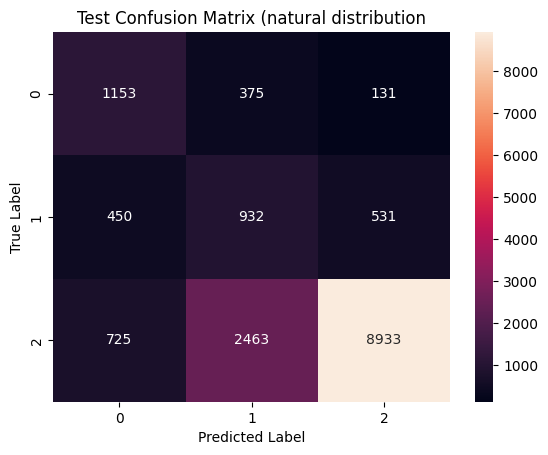

In [81]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, pred_test)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Test Confusion Matrix (natural distribution')
plt.show()

## 13. Validation

Same idea as the test evaluation above — the model and threshold are already locked in at
this point, so val is a pure, untouched final check rather than another tuning opportunity.

In [104]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

pred_val = best_pipeline.predict(X_val)


# 3. Evaluate
print(f"--- Logistic Validation Performance (default) ---")
print(f"Logistic_val Accuracy:  {accuracy_score(y_val, pred_val):.3f}")
print(
    'Precision:              '
    f" {precision_score(y_val, pred_val, average='macro', zero_division=0):.3f}"
)
print(
    'Recall:                 '
    f" {recall_score(y_val, pred_val, average='macro', zero_division=0):.3f}"
)
print(
    'F1-score:               '
    f" {f1_score(y_val, pred_val, average='macro', zero_division=0):.3f}"
)

print(
    classification_report(
        y_val, pred_val, zero_division=0, digits=3
    )
)

--- Logistic Validation Performance (default) ---
Logistic_val Accuracy:  0.706
Precision:               0.558
Recall:                  0.643
F1-score:                0.578
              precision    recall  f1-score   support

           0      0.492     0.700     0.578      1647
           1      0.251     0.488     0.332      1894
           2      0.930     0.740     0.824     12144

    accuracy                          0.706     15685
   macro avg      0.558     0.643     0.578     15685
weighted avg      0.802     0.706     0.739     15685



In [102]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

probs_val = best_pipeline.predict_proba(X_val)

pred_val = np.argmax(probs_val * best_weights, axis=1)

# 3. Evaluate
print(f"--- Logistic Validation Performance (Tuned Multipliers) ---")
print(f"Logistic_val Accuracy:  {accuracy_score(y_val, pred_val):.3f}")
print(
    'Precision:              '
    f" {precision_score(y_val, pred_val, average='macro', zero_division=0):.3f}"
)
print(
    'Recall:                 '
    f" {recall_score(y_val, pred_val, average='macro', zero_division=0):.3f}"
)
print(
    'F1-score:               '
    f" {f1_score(y_val, pred_val, average='macro', zero_division=0):.3f}"
)

print(
    classification_report(
        y_val, pred_val, zero_division=0, digits=3
    )
)

--- Logistic Validation Performance (Tuned Multipliers) ---
Logistic_val Accuracy:  0.699
Precision:               0.565
Recall:                  0.641
F1-score:                0.579
              precision    recall  f1-score   support

           0      0.518     0.675     0.586      1647
           1      0.245     0.518     0.333      1894
           2      0.931     0.730     0.819     12144

    accuracy                          0.699     15685
   macro avg      0.565     0.641     0.579     15685
weighted avg      0.805     0.699     0.735     15685



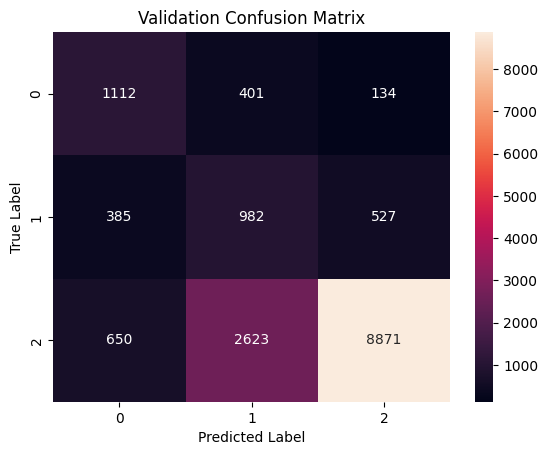

In [88]:
cm_val = confusion_matrix(y_val, pred_val)
sns.heatmap(cm_val, annot=True, fmt='d')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Validation Confusion Matrix')
plt.show()

## 14. Export finalized pipeline

**FIX:** export cell is now active (was fully commented out). Saves a single `Pipeline`
object (vectorizer + classifier together) plus the decision threshold and a bit of run
metadata, so there's one artifact to load at inference time instead of two files that have
to be kept manually in sync.

In [105]:
from datetime import datetime, timezone
import json
import os
import joblib
from sklearn.metrics import accuracy_score, f1_score

if exportModel:
    model_dir = os.path.join(os.path.dirname(os.getcwd()), "LR_models")
    os.makedirs(model_dir, exist_ok=True)

    # 1. Save the trained pipeline
    joblib.dump(best_pipeline, os.path.join(model_dir, "sentiment_pipeline.pkl"))

# 2. Prepare metadata config dictionary
    config = {
        "best_params": logistic_grid.best_params_,
        "cv_best_score_macro_f1": float(logistic_grid.best_score_),
        "test_accuracy": float(accuracy_score(y_test, pred_test)),
        "test_f1_macro": float(
            f1_score(y_test, pred_test, average="macro", zero_division=0)
        ),
        "test_f1_weighted": float(
            f1_score(y_test, pred_test, average="weighted", zero_division=0)
        ),
        "exported_at_utc": datetime.now(timezone.utc).isoformat(),
    }

    # 3. Save JSON metadata
    with open(os.path.join(model_dir, "model_config.json"), "w") as f:
        json.dump(config, f, indent=2)

    print(f"Pipeline and config exported to: {model_dir}")
else:
    print("exportModel is False - skipping export.")

Pipeline and config exported to: c:\Users\adham\OneDrive - Asia Pacific University\APU\DEGREE\LEVEL 3\SEM 1\sentiment analysis\assignment\Group Assignment Question-20260530\txsa part b\LR_models
